In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
import os
sys.path.append('../src')
from backtester import run_hmm_backtest

df_final = pd.read_csv(os.path.join('..', 'data', 'btc_usd_coinbase_features_with_wf.csv'))
df_final.head()

,Unnamed: 0,open,high,low,close,volume,log_return,volatility,trend_slope,volume_zscore,price_dist_ma,regime_wf_viterbi,prob_crash,prob_sideways,prob_bull,regime_wf_forward
0,2017-09-11,4251.36,4365.00,4111.14,4210.72,9068.255076,-0.009605,0.030313,0.043936,-0.866254,0.101060,2,0.276667,3.390316e-04,7.229944e-01,2
1,2017-09-12,4210.72,4375.37,4080.00,4164.52,12373.398578,-0.011033,0.030094,0.038617,-0.100017,0.081051,2,0.561752,4.122524e-04,4.378355e-01,0
2,2017-09-13,4164.52,4174.53,3726.00,3855.32,22842.532256,-0.077147,0.034406,0.037405,1.926841,-0.005878,0,0.907396,1.782211e-16,9.260365e-02,0
3,2017-09-14,3855.61,3923.00,3230.05,3250.40,36363.925012,-0.170676,0.048816,0.032372,3.120763,-0.164980,0,0.999987,2.408971e-61,1.286371e-05,0
4,2017-09-15,3249.99,3894.48,2975.01,3740.02,54488.482419,0.140313,0.059122,0.030400,3.409281,-0.044476,0,1.000000,3.312708e-61,7.824467e-16,0


In [17]:
# 1. Ganti nama kolom dari 'Unnamed: 0' menjadi 'date'
df_final = df_final.rename(columns={'Unnamed: 0': 'date'})

# 2. Ubah kolom 'date' menjadi tipe datetime
df_final['date'] = pd.to_datetime(df_final['date'])

# 3. (Opsional) Jadikan 'date' sebagai index agar visualisasi lebih rapi
df_final.set_index('date', inplace=True)

In [18]:
import joblib
dest_dir = os.path.join('..', 'models')
path_model=os.path.join(dest_dir, 'model_btc_v2.joblib')
model_btc_regime_v2 = joblib.load(path_model)

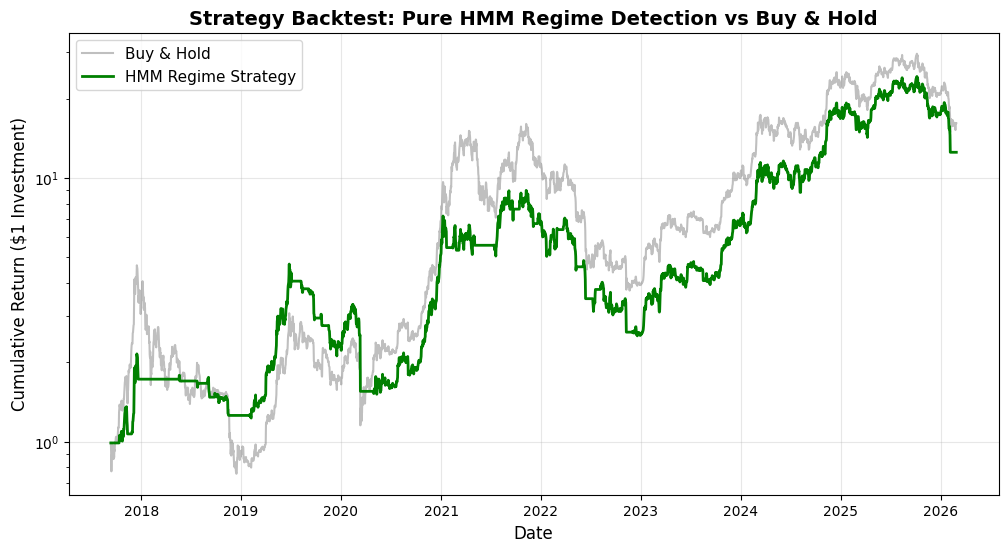

Hasil Akhir Investasi $1 (Pure HMM):
Buy & Hold  : $16.13
HMM Strategy: $12.52
Max Drawdown Strategi: -71.93%



In [19]:
df_for_backtest = df_final.copy() 

# Panggil fungsi backtester murni. 
# Fungsi ini otomatis membuat kolom 'signal', 'cum_bnh', dan 'cum_strategy'
df_for_backtest, stats = run_hmm_backtest(df_for_backtest, regime_col='regime_wf_forward', return_col='log_return')

# --- Visualisasi "The Money Shot" ---
plt.figure(figsize=(12, 6))
plt.plot(df_for_backtest.index, df_for_backtest['cum_bnh'], label='Buy & Hold', color='grey', alpha=0.5, linewidth=1.5)
plt.plot(df_for_backtest.index, df_for_backtest['cum_strategy'], label='HMM Regime Strategy', color='green', linewidth=2)

plt.title('Strategy Backtest: Pure HMM Regime Detection vs Buy & Hold', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return ($1 Investment)', fontsize=12)
plt.yscale('log') 
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# Print Statistik (Datanya diambil dari dictionary 'stats' hasil fungsi)
print(f"Hasil Akhir Investasi $1 (Pure HMM):")
print(f"Buy & Hold  : ${stats['Final_Value_BnH']:.2f}")
print(f"HMM Strategy: ${stats['Final_Value_Strategy']:.2f}")
print(f"Max Drawdown Strategi: {stats['Max_Drawdown_Strategy']:.2f}%\n")

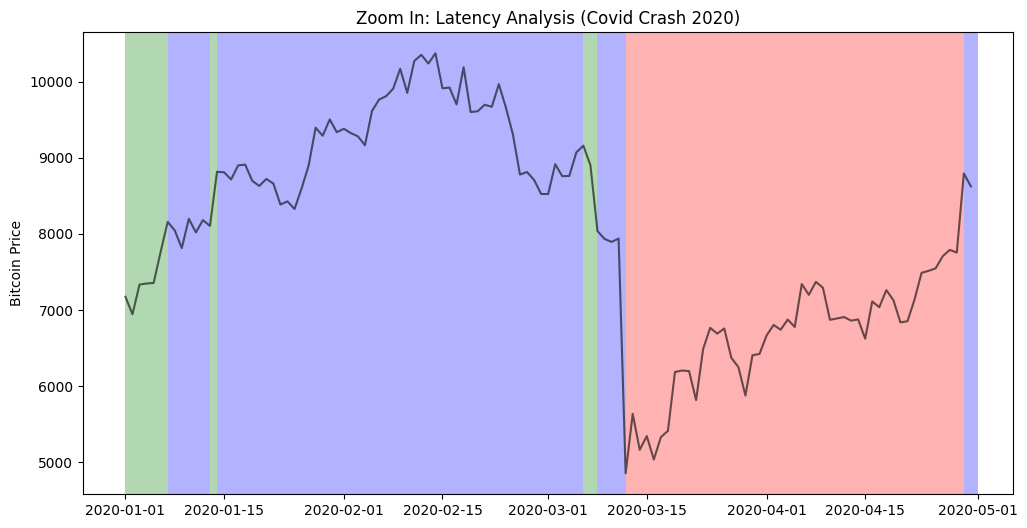

In [20]:
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

# Zoom in ke periode Crash Maret 2020
start_date = '2020-01-01'
end_date = '2020-04-30'

# Use df_for_backtest which contains the full history (btc_features_v2)
subset = df_for_backtest.loc[start_date:end_date]

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Harga
ax1.plot(subset.index, subset['close'], color='black', alpha=0.6, label='Price')
ax1.set_ylabel('Bitcoin Price', color='black')

# Plot Background warna sesuai Regime
# Merah = Crash, Hijau = Sideways, Biru = Bull
colors = ['red', 'green', 'blue'] # Sesuaikan urutan regime kamu (0, 1, 2)

# Trik visualisasi background
y_min, y_max = ax1.get_ylim()
for date, row in subset.iterrows():
    color = colors[int(row['regime_wf_forward'])] # Pastikan pakai 'regime_wf' untuk hasil walk-forward

    # Convert date to numerical format for matplotlib
    date_num = mdates.date2num(date)
    # Calculate the numerical width for one day
    width_num = mdates.date2num(date + pd.Timedelta(days=1)) - date_num

    # Gambar kotak warna per hari
    rect = Rectangle((date_num, y_min), width_num, y_max-y_min,
                     color=color, alpha=0.3, linewidth=0)
    ax1.add_patch(rect)

plt.title('Zoom In: Latency Analysis (Covid Crash 2020)')
plt.show()

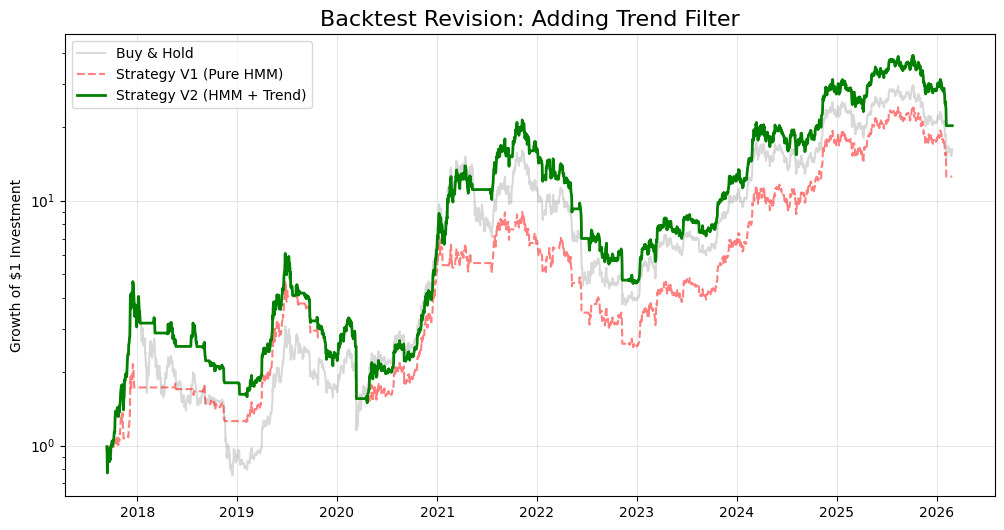

Hasil Akhir Strategy V2 (Trend Filter): $20.21
Max Drawdown Strategy V2: -78.52%


In [21]:
# Ambil dari df_final lagi karena df_for_backtest baris NaN-nya sudah dihapus oleh fungsi
df_strategy_v2 = df_final.copy() 

# 1. Definisikan Tren Jangka Panjang
df_strategy_v2['long_term_trend'] = df_strategy_v2['close'].rolling(window=50).mean()

# 2. Buat Signal Baru dengan Filter (PERBAIKAN: Crash adalah 0, bukan 1)
condition_crash = (df_strategy_v2['regime_wf_forward'] == 0) 
condition_downtrend = (df_strategy_v2['close'] < df_strategy_v2['long_term_trend'])

df_strategy_v2['signal_v2'] = np.where(condition_crash & condition_downtrend, 0, 1)
df_strategy_v2['signal_v2'] = df_strategy_v2['signal_v2'].shift(1)

# 3. Hitung Profit
df_strategy_v2['strategy_v2_return'] = df_strategy_v2['log_return'] * df_strategy_v2['signal_v2']
df_strategy_v2['cum_strategy_v2'] = df_strategy_v2['strategy_v2_return'].cumsum().apply(np.exp)

df_strategy_v2.dropna(subset=['cum_strategy_v2'], inplace=True)

# --- VISUALISASI PERBANDINGAN ---
plt.figure(figsize=(12, 6))
# BnH dihitung ulang sedikit agar indexnya pas
plt.plot(df_strategy_v2.index, df_strategy_v2['log_return'].cumsum().apply(np.exp), label='Buy & Hold', color='grey', alpha=0.3)
plt.plot(df_for_backtest.index, df_for_backtest['cum_strategy'], label='Strategy V1 (Pure HMM)', color='red', alpha=0.5, linestyle='--')
plt.plot(df_strategy_v2.index, df_strategy_v2['cum_strategy_v2'], label='Strategy V2 (HMM + Trend)', color='green', linewidth=2)

plt.title('Backtest Revision: Adding Trend Filter', fontsize=16)
plt.ylabel('Growth of $1 Investment')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print Statistik Akhir V2
final_v2 = df_strategy_v2['cum_strategy_v2'].iloc[-1]
running_max_v2 = df_strategy_v2['cum_strategy_v2'].cummax()
drawdown_v2 = (df_strategy_v2['cum_strategy_v2'] - running_max_v2) / running_max_v2

print(f"Hasil Akhir Strategy V2 (Trend Filter): ${final_v2:.2f}")
print(f"Max Drawdown Strategy V2: {drawdown_v2.min()*100:.2f}%")

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
sys.path.append('../src')
from backtester import run_hmm_backtest

df_final = pd.read_csv(os.path.join('..', 'data', 'btc_usd_coinbase_features_with_wf.csv'))
df_final.head()

,Unnamed: 0,open,high,low,close,volume,log_return,volatility,trend_slope,volume_zscore,price_dist_ma,regime_wf_viterbi,prob_crash,prob_sideways,prob_bull,regime_wf_forward
0,2017-09-11,4251.36,4365.00,4111.14,4210.72,9068.255076,-0.009605,0.030313,0.043936,-0.866254,0.101060,2,0.276667,3.390316e-04,7.229944e-01,2
1,2017-09-12,4210.72,4375.37,4080.00,4164.52,12373.398578,-0.011033,0.030094,0.038617,-0.100017,0.081051,2,0.561752,4.122524e-04,4.378355e-01,0
2,2017-09-13,4164.52,4174.53,3726.00,3855.32,22842.532256,-0.077147,0.034406,0.037405,1.926841,-0.005878,0,0.907396,1.782211e-16,9.260365e-02,0
3,2017-09-14,3855.61,3923.00,3230.05,3250.40,36363.925012,-0.170676,0.048816,0.032372,3.120763,-0.164980,0,0.999987,2.408971e-61,1.286371e-05,0
4,2017-09-15,3249.99,3894.48,2975.01,3740.02,54488.482419,0.140313,0.059122,0.030400,3.409281,-0.044476,0,1.000000,3.312708e-61,7.824467e-16,0


## pakai strategi

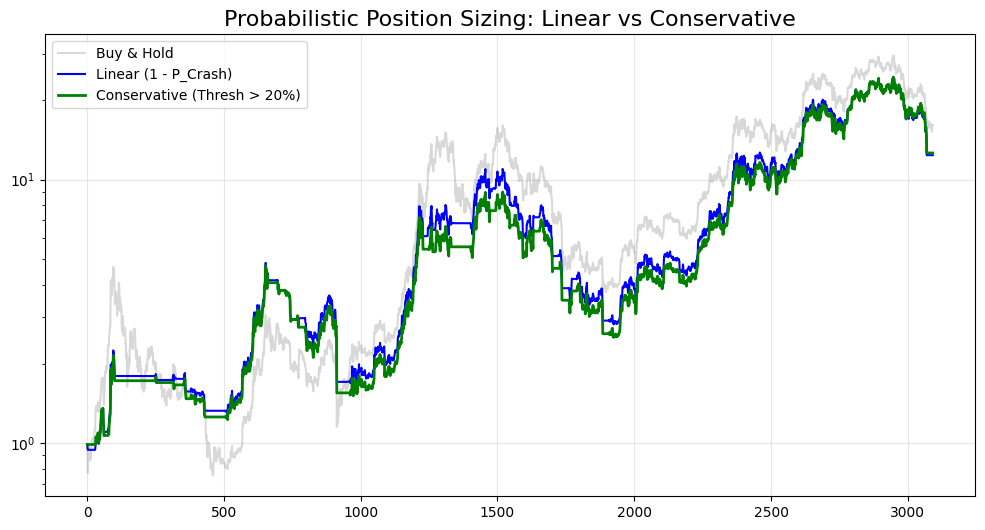

Buy & Hold Profit: $16.13 (DD: -83.80%)
Linear Strategy  : $12.39 (DD: -74.28%)
Conservative     : $12.62 (DD: -71.93%)


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Copy dataframe hasil walk-forward
df_prob_strategy = df_final.copy()

# --- DEFINISI STRATEGI PROBABILISTIK ---

# 1. Strategy A: Linear Inverse Risk
# "Saya investasi sebesar keyakinan saya bahwa pasar TIDAK AKAN crash"
# Rumus: Exposure = 1 - Probabilitas Crash
df_prob_strategy['pos_linear'] = 1.0 - df_prob_strategy['prob_crash']

# 2. Strategy B: Conservative Threshold (Panic Filter)
# "Kalau peluang crash di atas 20%, saya keluar SEMUA. Kalau di bawah itu, saya invest full."
# Ini untuk menghindari "slow bleed"
df_prob_strategy['pos_conservative'] = np.where(df_prob_strategy['prob_crash'] > 0.50, 0.0, 1.0)

# 3. Strategy C: Smart Weighted (Bull + 0.5 Sideways)
# "Saya full gas pas Bull, setengah gas pas Sideways, rem blong pas Crash"
df_prob_strategy['pos_weighted'] = df_prob_strategy['prob_bull'] + (0.5 * df_prob_strategy['prob_sideways'])

# --- SHIFT 1 HARI (WAJIB) ---
# Kita hitung probabilitas penutupan hari ini untuk set posisi BESOK pagi
cols_to_shift = ['pos_linear', 'pos_conservative', 'pos_weighted']
df_prob_strategy[cols_to_shift] = df_prob_strategy[cols_to_shift].shift(1)

# Hapus NaN awal
df_prob_strategy.dropna(subset=cols_to_shift, inplace=True)

# --- HITUNG PROFIT ---
# Return = Log Return * Besaran Posisi (0.0 sampai 1.0)
df_prob_strategy['ret_linear'] = df_prob_strategy['log_return'] * df_prob_strategy['pos_linear']
df_prob_strategy['ret_conservative'] = df_prob_strategy['log_return'] * df_prob_strategy['pos_conservative']
df_prob_strategy['ret_weighted'] = df_prob_strategy['log_return'] * df_prob_strategy['pos_weighted']

# Cumulative Return
df_prob_strategy['cum_bnh'] = df_prob_strategy['log_return'].cumsum().apply(np.exp)
df_prob_strategy['cum_linear'] = df_prob_strategy['ret_linear'].cumsum().apply(np.exp)
df_prob_strategy['cum_conservative'] = df_prob_strategy['ret_conservative'].cumsum().apply(np.exp)
df_prob_strategy['cum_weighted'] = df_prob_strategy['ret_weighted'].cumsum().apply(np.exp)

# --- VISUALISASI ---
plt.figure(figsize=(12, 6))
plt.plot(df_prob_strategy.index, df_prob_strategy['cum_bnh'], label='Buy & Hold', color='grey', alpha=0.3)
plt.plot(df_prob_strategy.index, df_prob_strategy['cum_linear'], label='Linear (1 - P_Crash)', color='blue', linewidth=1.5)
plt.plot(df_prob_strategy.index, df_prob_strategy['cum_conservative'], label='Conservative (Thresh > 20%)', color='green', linewidth=2)
# plt.plot(df_prob_strategy.index, df_prob_strategy['cum_weighted'], label='Weighted', color='orange', linestyle='--')

plt.title('Probabilistic Position Sizing: Linear vs Conservative', fontsize=16)
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- STATISTIK ---
# Fungsi bantu hitung drawdown
def get_dd(series):
    return ((series - series.cummax()) / series.cummax()).min() * 100

print(f"Buy & Hold Profit: ${df_prob_strategy['cum_bnh'].iloc[-1]:.2f} (DD: {get_dd(df_prob_strategy['cum_bnh']):.2f}%)")
print(f"Linear Strategy  : ${df_prob_strategy['cum_linear'].iloc[-1]:.2f} (DD: {get_dd(df_prob_strategy['cum_linear']):.2f}%)")
print(f"Conservative     : ${df_prob_strategy['cum_conservative'].iloc[-1]:.2f} (DD: {get_dd(df_prob_strategy['cum_conservative']):.2f}%)")